# Source: https://scikit-learn.org/stable/auto_examples/decomposition/plot_image_denoising.html

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import sklearn
import scipy.linalg as LA
import matplotlib.pyplot as plt

from time import time
from sklearn.decomposition import SparseCoder, sparse_encode
from sklearn.linear_model import orthogonal_mp_gram

seed = 42
rng = np.random.default_rng(seed)

## Import test image from scipy

In [2]:
from scipy.datasets import face

raccoon_face = face(gray=True).astype(np.float64)

# normalize
raccoon_face /= 255.0

# downsample for speed
raccoon_face = raccoon_face[::4, ::4] + raccoon_face[2::4, ::4] + raccoon_face[::4, 2::4] + raccoon_face[2::4, 2::4]
raccoon_face /= 4
height, width = raccoon_face.shape

# Distort the right half of the image
print('Distorting image')
distorted = raccoon_face.copy()
distorted[:, width // 2:] += .075 * rng.standard_normal(size=(height, width // 2))

Distorting image


## Display distorted image

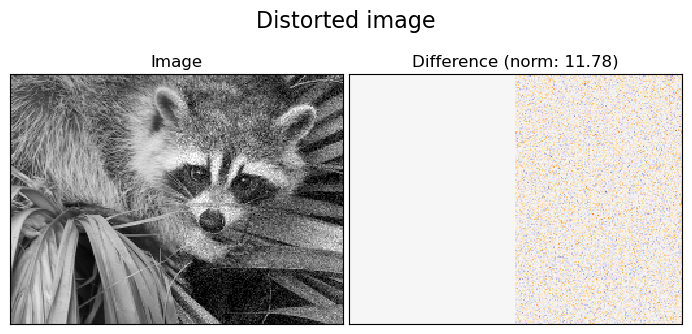

In [3]:
def show_with_diff(image, reference, title):
    plt.figure(figsize=(7, 3.3))
    plt.subplot(1, 2, 1)
    plt.title('Image')
    plt.imshow(image, vmin=0, vmax=1, cmap=plt.cm.gray, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
    
    plt.subplot(1, 2, 2)
    difference = image - reference

    plt.title('Difference (norm: %.2f)' % np.sqrt(np.sum(difference**2)))
    plt.imshow(
        difference, vmin=-0.5, vmax=0.5, cmap=plt.cm.PuOr, interpolation='nearest'
    )
    plt.xticks(())
    plt.yticks(())
    plt.suptitle(title, size=16)
    plt.subplots_adjust(.02, .02, .98, .79, .02, .2)

show_with_diff(distorted, raccoon_face, 'Distorted image')

## Extract reference patches

In [4]:
from time import time
from sklearn.feature_extraction.image import extract_patches_2d

# Extract patches from left half of the image
print('Extracting reference patches')
t0 = time()
patch_size = (7, 7)
data = extract_patches_2d(distorted[:, :width // 2], patch_size)
data = data.reshape(data.shape[0], -1)
data -= np.mean(data, axis=0)
data /= np.std(data, axis=0)
print(f'{data.shape[0]} patches extracted in %.2fs.' % (time() - t0))

Extracting reference patches
22692 patches extracted in 0.01s.


# Best Serial KSVD implementation

In [5]:
def OMP(Y, T_0, D, batch_size = 1, rng=42, debug=False):
    # loss = np.empty(num_iter)
    # rng = np.random.default_rng(rng)

    X = np.zeros((Y.shape[0], D.shape[0]))
    D_norm = np.linalg.norm(D, axis=1, keepdims=True)

    splits = np.arange(0, Y.shape[0], step=batch_size)
    Y_batches = np.split(Y, splits)[1:]
    
    for i, y in enumerate(Y_batches):
        if i == (len(Y_batches) - 1):
            batch_size = np.arange(splits[i], len(Y)).shape[0]
            if debug:
                print(f'batch_size = {batch_size}')
        I = np.empty((batch_size, T_0), dtype=np.int32)
        D_I = np.zeros((batch_size, T_0, D.shape[1]))
        r = y   # (batch_size, D.shape[1])
        gamma = 0
        Q = np.empty((batch_size, D.shape[1], T_0))
        R = np.empty((batch_size, T_0, T_0))
        
        for j in range(T_0):
            if debug:
                print(f'Batch {i}, Iteration {j}')
                print(f'r shape: {r.shape}')
            D_r = np.abs(r @ D.T)
            k = np.argmax(D_r, axis = 1)
            
            I[:, j] = k
            D_I[:, j] = D[k]

            if j == 0:
                D_k_norm = D_norm[k]
                R[:, 0, 0] = D_k_norm[:, 0]
                Q[:, :, 0] = D[k] / D_k_norm
                
                if debug:
                    print(D_k_norm)
                    print(np.sum(Q[:, :, 0] ** 2, axis = 1))
                    print(R[:, 0, 0])

                gamma = np.squeeze(y[:, np.newaxis] @ Q[:, :, :1], axis=1) 
                gamma /= D_k_norm
                
            else:
                if debug:
                    print(np.transpose(Q[:, :, :j], (0, 2, 1)).shape)
                    print(D[k][..., np.newaxis].shape)
                # dot = np.transpose(Q[:, :, :j], (0, 2, 1)) @ D[k][..., np.newaxis]
                dot = np.squeeze(D[k][:, np.newaxis] @ Q[:, :, :j], axis=1)
                
                # R[:, 0:j, j] = dot[0]
                R[:, 0:j, j] = dot
                
                # q_j = D[k] - (Q[:, :, :j] @ dot)[..., 0]
                q_j = D[k] - np.squeeze(Q[:, :, :j] @ dot[..., np.newaxis], axis = -1)
                
                # q_j_norm = np.linalg.norm(q_j)
                q_j_norm = np.linalg.norm(q_j, axis = 1)
                
                R[:, j, j] = q_j_norm
                # Q[:, :, j] = q_j / q_j_norm
                Q[:, :, j] = q_j / q_j_norm[:, np.newaxis]
                

                if debug:            
                    print(Q[:, :, :j+1].shape)
                    print(y.shape)
                Q_T_y = np.transpose(y[:, np.newaxis] @ Q[:, :, :j+1], (0, 2, 1))
                gamma = LA.solve_triangular(R[:, :j+1, :j+1], 
                                        Q_T_y, 
                                        overwrite_b = True,
                                        check_finite = False)
                if debug:
                    print(f'original gamma shape: {gamma.shape}')
                # gamma = np.transpose(gamma, (0, 2, 1))
                gamma = np.squeeze(gamma, axis=-1)
                

            if debug:
                print(gamma.shape)
                print(f'D_I shape: {D_I[:, :j+1].shape}')
                print(f'y shape: {y.shape}')
            # est = (np.transpose(D_I[:, :j+1], (0, 2, 1)) @ gamma[..., np.newaxis])[..., 0] 
            est = np.squeeze(gamma[:, np.newaxis] @ D_I[:, :j+1], axis=1)
            if debug:
                print(f'est shape: {est.shape}')
            r = y - est
            # if r.ndim > 2:
                # r = np.transpose(r, (0, 2, 1))
            if debug:
                print(r.shape)
            if debug:
                print(np.sum(r * r, axis = -1))
                # print(res)

        # X[i, I] = gamma
        if i == (len(Y_batches) - 1):
            if debug:
                # print(splits[i].dtype)
                # print(I.dtype)
                print(f'gamma: {gamma}')
                print(f'gamma shape: {gamma.shape}')
                print(f'k shape: {k.shape}')
                print(f'I shape: {I.shape}')
            # if T_0 == 1:
            #     X[np.arange(splits[i], len(Y)), I[:, 0]] = gamma[:, 0]
            # else:
            #     X[np.arange(splits[i], len(Y))[:, np.newaxis], I] = gamma[:, 0, :]
            X[np.arange(splits[i], len(Y))[:, np.newaxis], I] = gamma
            
        elif i == 0:
            X[np.arange(0, splits[1])[:, np.newaxis], I] = gamma
        else:
            X[np.arange(splits[i], splits[i+1])[:, np.newaxis], I] = gamma

        if debug:
            print()
    return X


def kSVD(Y, T_0, k, num_iter, batch_size = 1, track_loss = True, verbose:int = 0, rng=42):
    loss = np.empty(num_iter)
    rng = np.random.default_rng(rng)

    # Initialize dictionary
    t0 = time()
    D = rng.standard_normal(size=(k, Y.shape[1]))
    D /= LA.norm(D, ord=2, axis=1)[:, np.newaxis]

    if verbose > 0:
        print(f'Initialization Time: {time() - t0}')
    
    for iter in range(num_iter):
        t0 = 0
        if verbose > 0:
            print(f'Iteration {iter}:')
            t0 = time()
        
        # gram = D @ D.T
        # cov = D @ Y.T
        # X = orthogonal_mp_gram(
        #     Gram=gram, 
        #     Xy=cov, 
        #     n_nonzero_coefs=T_0, 
        #     copy_Gram=False, 
        #     copy_Xy=False
        # ).T # Transpose to match X shape
        X = OMP(Y, T_0, D, batch_size = batch_size, rng=rng, debug=False)
        # X = np.asfortranarray(X)
        if verbose > 0:
            print(f'\tCoding Time: {time() - t0}')
        
        t0 = time()
        unused_atom = False
        # XD = X @ D
        filter_bool = (X != 0)
        E_k_R = Y - X @ D
        for i in range(k):
            # x_i = X[:, i]
            filter_bool_i = filter_bool[:, i]
            
            # filter = np.flatnonzero(x_i)
            # filter = np.nonzero(x_i)[0]
            filter = np.flatnonzero(filter_bool_i)
            
            # x_i_R = x_i[filter]
            
            # if x_i_R.shape[0] == 0:
            if filter.shape[0] == 0:
                unused_atom=True
                continue
            
            # res = X[filter, i][:, np.newaxis] * D[i]
            # XD[filter] -= res
            # E_k_R = Y[filter] - XD[filter]
            E_k_R[filter] += X[filter, i][:, np.newaxis] * D[i]

            # U, S, Vh = LA.svd(E_k_R, full_matrices=False)
            # U, S, Vh = LA.svd(E_k_R[filter], full_matrices=False)
            U, S, Vh = np.linalg.svd(E_k_R[filter], full_matrices=False)

            X[filter, i] = U[:, 0] * S[0]
            D[i] = Vh[0]

            # XD[filter] += X[filter, i][:, np.newaxis] * D[i]
            E_k_R[filter] -= X[filter, i][:, np.newaxis] * D[i]

        if verbose > 0:
            print(f'\tUpdate Time: {time() - t0}')
            print(f'\tUnused Atom: {unused_atom}')
        
        # loss[iter] = LA.norm(Y - XD, ord='fro')
        loss[iter] = LA.norm(E_k_R, ord='fro')

    return D, loss

In [6]:
def plot_log_loss(loss, linestyle='-', alpha = 1):
    plt.semilogy(loss, linestyle=linestyle, alpha = alpha)
    plt.title('Loss vs iterations')
    plt.xlabel('Iteration')
    plt.ylabel('Loss (Log Scale)')
    # plt.show()

## Learn the dictionary from reference patches

### Hyperparams have been set to try to match those in the sklearn example and the results obtained for a more fair comparison!

In [7]:
num_iter = 2
Y = data
batch_size = 256

Learning the dictionary
Initialization Time: 0.0
Iteration 0:
	Coding Time: 0.09000015258789062
	Update Time: 0.20402765274047852
	Unused Atom: True
Iteration 1:
	Coding Time: 0.042002201080322266
	Update Time: 0.14500069618225098
	Unused Atom: True
Total Time: 0.49.


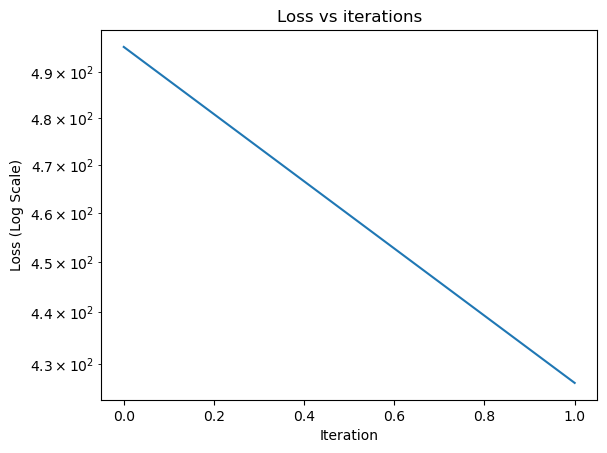

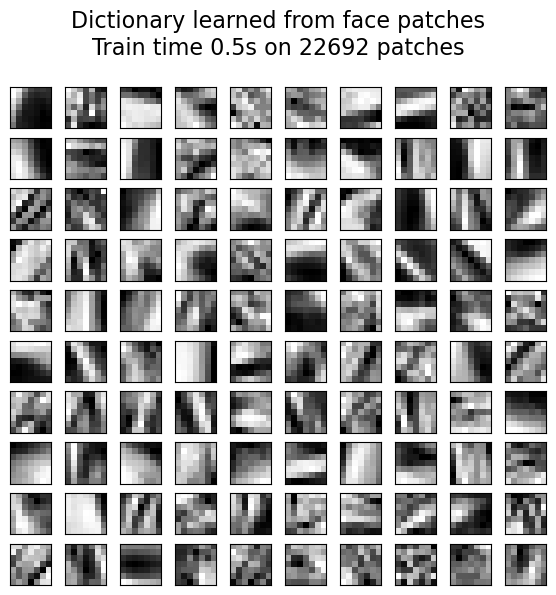

In [8]:
print('Learning the dictionary')
t0 = time()
D, loss = kSVD(Y = Y, 
               T_0 = 1, 
               k = 300, 
               num_iter = num_iter, 
               verbose=1,
               rng = rng,
               batch_size = batch_size)
dt = time() - t0
print(f'Total Time: {dt:.2f}.')
plot_log_loss(loss)

plt.figure(figsize=(6.5, 6))
for i, comp in enumerate(D[:100]):
    plt.subplot(10, 10, i+1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    'Dictionary learned from face patches\n'
    + 'Train time %.1fs on %d patches' % (dt, len(Y)),
    fontsize=16,
)
plt.subplots_adjust(.08, .02, .92, .85, .08, .23)

## Extract noisy patches and reconstruct them using the dictionary

In [9]:
from sklearn.feature_extraction.image import reconstruct_from_patches_2d

print('Extracting noisy patches...')
t0 = time()
data_test = extract_patches_2d(distorted[:, width // 2 :], patch_size)
data_test = data_test.reshape(data_test.shape[0], -1)
intercept = np.mean(data_test, axis=0)
data_test -= intercept
print('done in %.2fs.' % (time() - t0))

Extracting noisy patches...
done in 0.00s.


OMP
1 atom...
done in 1.59s.
OMP
2 atoms...
done in 3.19s.
Lars
4 atoms...
done in 15.23s.
Thresholding
 alpha = 0.1...
done in 0.34s.


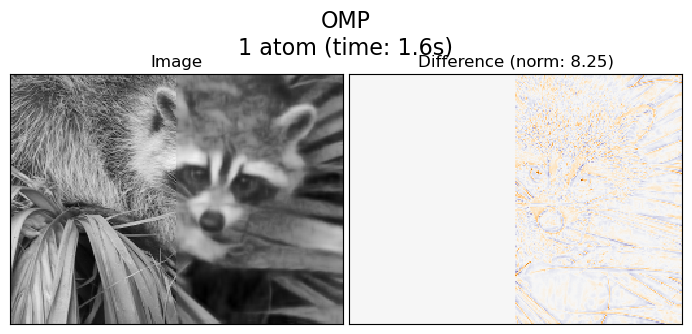

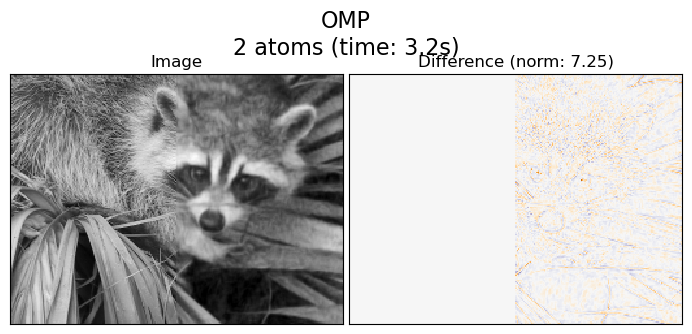

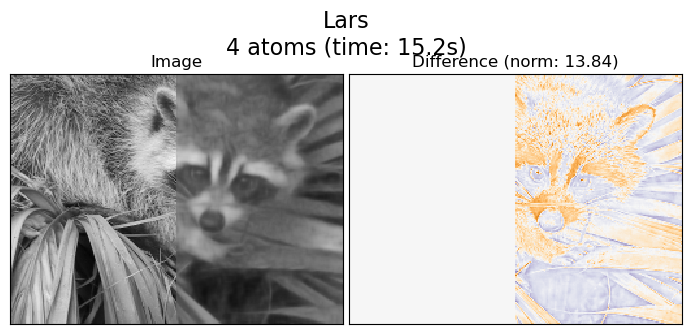

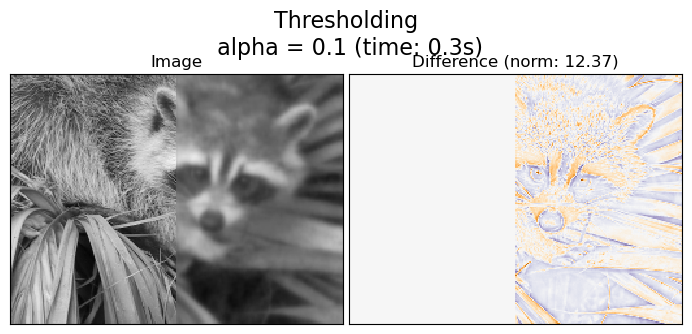

In [10]:
transform_algorithms = [
('OMP\n1 atom', 'omp', {'transform_n_nonzero_coefs': 1}),
('OMP\n2 atoms', 'omp', {'transform_n_nonzero_coefs': 2}),
('Lars\n4 atoms', 'lars', {'transform_n_nonzero_coefs': 4}),
('Thresholding\n alpha = 0.1', 'threshold', {'transform_alpha': 0.1}),
]

reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    coder = SparseCoder(transform_algorithm=transform_algorithm,
                        dictionary = D,
                        **kwargs)
    code = coder.transform(data_test)
    patches = code @ D

    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    if transform_algorithm == 'threshold':
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()

# Compare with MiniBatchDictionaryLearning used in the scikit-learn example

Learning the dictionary...
1.0 iterations / 101 steps in 34.98.


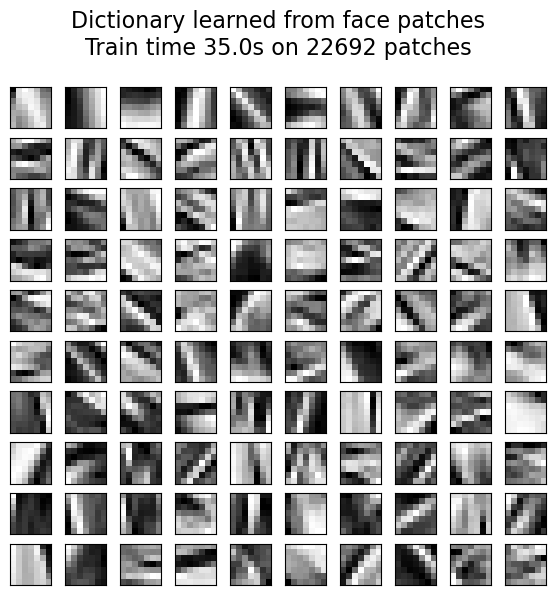

In [11]:
from sklearn.decomposition import MiniBatchDictionaryLearning

print('Learning the dictionary...')
t0 = time()
dico = MiniBatchDictionaryLearning(
    n_components=300,
    batch_size=200,
    alpha=1.0,
    max_iter=10,
    random_state = seed,
)
V = dico.fit(data).components_
dt = time() - t0
print(f'{dico.n_iter_} iterations / {dico.n_steps_} steps in {dt:.2f}.')

plt.figure(figsize=(6.5, 6))
for i, comp in enumerate(V[:100]):
    plt.subplot(10, 10, i+1)
    plt.imshow(comp.reshape(patch_size), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.xticks(())
    plt.yticks(())
plt.suptitle(
    'Dictionary learned from face patches\n'
    + 'Train time %.1fs on %d patches' % (dt, len(data)),
    fontsize=16,
)
plt.subplots_adjust(.08, .02, .92, .85, .08, .23)

OMP
1 atom...
done in 1.91s.
OMP
2 atoms...
done in 3.29s.
Lars
4 atoms...
done in 15.21s.
Thresholding
 alpha = 0.1...
done in 0.28s.


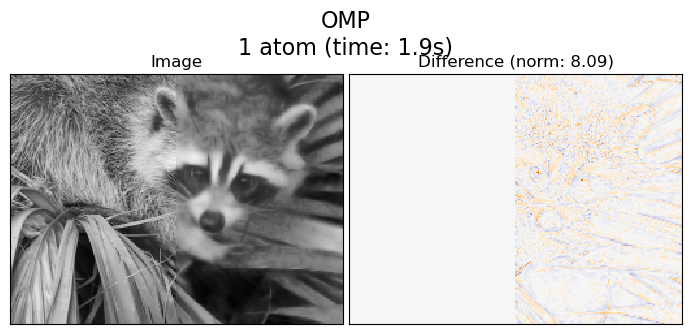

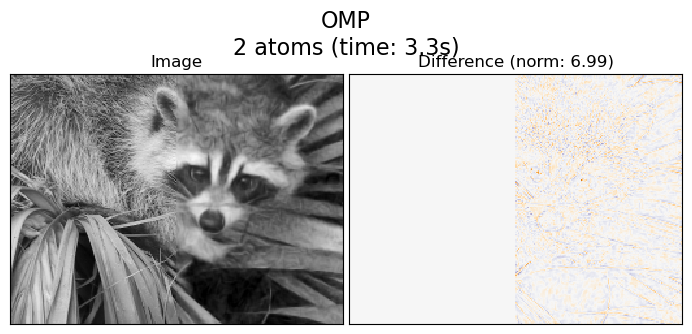

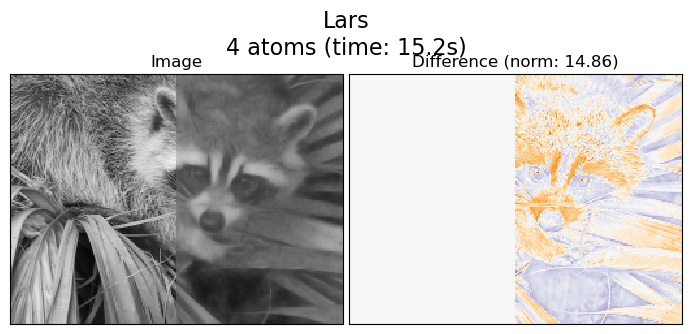

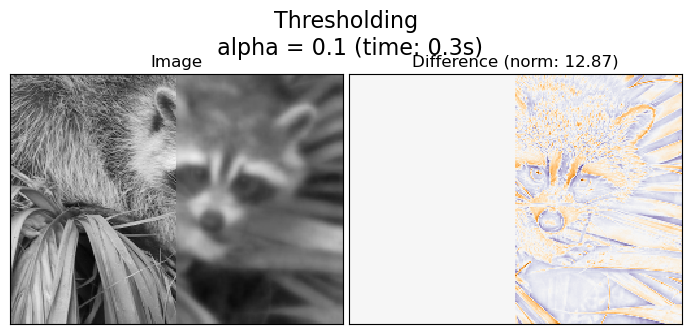

In [12]:
reconstructions = {}
for title, transform_algorithm, kwargs in transform_algorithms:
    print(title + '...')
    reconstructions[title] = raccoon_face.copy()
    t0 = time()
    # coder = SparseCoder(transform_algorithm=transform_algorithm,
    #                     dictionary = D,
    #                     **kwargs)
    # code = coder.transform(data_test)
    # patches = code @ D
    
    dico.set_params(transform_algorithm=transform_algorithm, **kwargs)
    code = dico.transform(data_test)
    patches = np.dot(code, V)
    
    patches += intercept
    patches = patches.reshape(len(data_test), *patch_size)
    if transform_algorithm == 'threshold':
        patches -= patches.min()
        patches /= patches.max()
    reconstructions[title][:, width // 2 :] = reconstruct_from_patches_2d(
        patches, (height, width // 2)
    )
    dt = time() - t0
    print('done in %.2fs.' % dt)
    show_with_diff(reconstructions[title], 
                   raccoon_face, 
                   title + ' (time: %.1fs)' % dt
                  )

plt.show()